# Pseudobulk Generator Demo

This notebook demonstrates the refactored pseudobulk generation pipeline, showcasing:

1. **Data structures** - `GenerationMetadata`, `GenerationParameters`, `PseudobulkResult`
2. **Checkpoint management** - Crash-resilient checkpointing with atomic writes
3. **HDF5 batch writing** - Atomic batch file operations
4. **Single pseudobulk generation** - Core sampling and aggregation
5. **Full pipeline** - End-to-end generation with `PseudobulkGenerator`
6. **Output inspection** - Reading and exploring the HDF5 output

## 1. Setup and Imports

In [1]:
import tempfile
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt

# Import the refactored pseudobulk generator components
from syto.data.pseudobulk_generator import (
    PseudobulkGenerator,
    _sample_reads_per_grg_uniform_multinomial,
    _sample_read_ids_from_grouped_dataframe,
)
from syto.data.hdf5_utils import (
    HDF5Schema,
    PseudobulkResult,
    PureProfileResult,
    GenerationMetadata,
    GenerationParameters,
    CheckpointManager,
    HDF5BatchWriter,
    SplitCheckpoint,
    GenerationConfig,
)

%load_ext autoreload
%autoreload 2

print("All imports successful!")

All imports successful!


## 2. Create Synthetic Data

We'll create a minimal synthetic dataset to demonstrate the pipeline without requiring actual methylation data.

In [2]:
def create_synthetic_split_df(n_classes: int = 5, n_gr_groups: int = 10, reads_per_group: int = 50):
    """Create a synthetic read-level prediction DataFrame.
    
    Args:
        n_classes: Number of cell type classes
        n_gr_groups: Number of genomic region groups
        reads_per_group: Number of reads per (class, GRG) combination
    """
    rows = []
    
    for class_label in range(n_classes):
        for grg_label in range(n_gr_groups):
            for read_idx in range(reads_per_group):
                # Generate prediction probabilities (slightly biased toward true class)
                predictions = np.random.dirichlet(np.ones(n_classes) * 0.5)
                predictions[class_label] += 0.3  # Bias toward true class
                predictions /= predictions.sum()  # Renormalize
                
                row = {
                    "original_label": class_label,
                    "dmr_ctype_label": grg_label,
                    "dmr_ctype": f"ctype_{grg_label}",
                    "name": f"region_{class_label}_{grg_label}_{read_idx}",
                    "chr": f"chr{(grg_label % 22) + 1}",
                    "NCPGS": np.random.randint(2, 10),
                    "M_rate": np.random.uniform(0, 1),
                    "label": class_label,
                }
                
                # Add prediction columns
                for i, pred in enumerate(predictions):
                    row[f"prediction_{i}"] = pred
                
                rows.append(row)
    
    return pd.DataFrame(rows)

# Create synthetic data with 5 classes and 10 GR groups
N_CLASSES = 5
N_GR_GROUPS = 10

train_df = create_synthetic_split_df(N_CLASSES, N_GR_GROUPS, reads_per_group=100)
valid_df = create_synthetic_split_df(N_CLASSES, N_GR_GROUPS, reads_per_group=50)
test_df = create_synthetic_split_df(N_CLASSES, N_GR_GROUPS, reads_per_group=50)

print(f"Train DataFrame: {train_df.shape}")
print(f"Valid DataFrame: {valid_df.shape}")
print(f"Test DataFrame: {test_df.shape}")
train_df.head()

Train DataFrame: (5000, 13)
Valid DataFrame: (2500, 13)
Test DataFrame: (2500, 13)


,original_label,dmr_ctype_label,dmr_ctype,name,chr,NCPGS,M_rate,label,prediction_0,prediction_1,prediction_2,prediction_3,prediction_4
0,0,0,ctype_0,region_0_0_0,chr1,8,0.978781,0,0.660438,0.084049,0.020773,0.227506,0.007235
1,0,0,ctype_0,region_0_0_1,chr1,9,0.151254,0,0.430144,0.037022,0.117919,0.110723,0.304193
2,0,0,ctype_0,region_0_0_2,chr1,5,0.251667,0,0.433510,0.043836,0.302956,0.000017,0.219681
3,0,0,ctype_0,region_0_0_3,chr1,9,0.442139,0,0.507505,0.035000,0.080298,0.136812,0.240385
4,0,0,ctype_0,region_0_0_4,chr1,2,0.615570,0,0.248309,0.066125,0.001212,0.153869,0.530485


## 3. Data Structures

### 3.1 GenerationMetadata
Stores metadata about the generation process (classifier used, labeling scheme, etc.)

In [3]:
# Create metadata about the generation
metadata = GenerationMetadata(
    gr_id_column="dmr_ctype_label",
    labeling_scheme="soft_labels",
    classifier="XGBoost_v2",
    data_watermark="demo_synthetic_data_2026",
    data_stats={
        "n_train_reads": len(train_df),
        "n_valid_reads": len(valid_df),
        "n_test_reads": len(test_df),
    }
)

print("Metadata:")
for k, v in metadata.to_dict().items():
    print(f"  {k}: {v}")

Metadata:
  gr_id_column: dmr_ctype_label
  labeling_scheme: soft_labels
  classifier: XGBoost_v2
  data_watermark: demo_synthetic_data_2026
  data_stats: {'n_train_reads': 5000, 'n_valid_reads': 2500, 'n_test_reads': 2500}


### 3.2 GenerationParameters
Stores generation parameters (cell types mapping, substitution method, etc.)

In [19]:
# Create generation parameters
parameters = GenerationParameters(
    cell_types_mapping={f"CellType_{i}": i for i in range(N_CLASSES)},
    gr_groups={f"grg_ctype_{i}": i for i in range(N_GR_GROUPS)},
    substitution_method="uniform_number",
    gr_sampling_method="uniform_multinomial",
)

print("Parameters:")
print(f"  Cell types: {parameters.cell_types_mapping}")
print(f"  GR groups: {list(parameters.gr_groups.items())[:3]}... ({len(parameters.gr_groups)} total)")
print(f"  Substitution method: {parameters.substitution_method}")
print(f"  Sampling method: {parameters.gr_sampling_method}")
print(f"\nParameters hash (for change detection): {parameters.to_hash()}")

Parameters:
  Cell types: {'CellType_0': 0, 'CellType_1': 1, 'CellType_2': 2, 'CellType_3': 3, 'CellType_4': 4}
  GR groups: [('grg_ctype_0', 0), ('grg_ctype_1', 1), ('grg_ctype_2', 2)]... (10 total)
  Substitution method: uniform_number
  Sampling method: uniform_multinomial

Parameters hash (for change detection): bc85e70da2a94eff


### 3.3 PseudobulkResult
Stores the result of generating a single pseudobulk sample

In [20]:
# Example PseudobulkResult
example_result = PseudobulkResult(
    index=0,
    target_proportions=np.array([0.4, 0.3, 0.2, 0.05, 0.05]),
    actual_proportions=np.array([0.39, 0.31, 0.19, 0.06, 0.05]),
    actual_n_reads_sampled=1000,
    n_samples_per_class_per_grg=np.random.randint(5, 50, size=(N_CLASSES, N_GR_GROUPS)),
    seed=42,
    aggregated_features=pd.DataFrame({
        "prediction_0_wavg": np.random.rand(N_GR_GROUPS),
        "prediction_1_wavg": np.random.rand(N_GR_GROUPS),
    })
)

print(f"PseudobulkResult index: {example_result.index}")
print(f"Target proportions: {example_result.target_proportions}")
print(f"Actual proportions: {example_result.actual_proportions}")
print(f"Seed (for reproducibility): {example_result.seed}")
print(f"Aggregated features shape: {example_result.aggregated_features.shape}")

PseudobulkResult index: 0
Target proportions: [0.4  0.3  0.2  0.05 0.05]
Actual proportions: [0.39 0.31 0.19 0.06 0.05]
Seed (for reproducibility): 42
Aggregated features shape: (10, 2)


## 4. Checkpoint Management

The `CheckpointManager` provides crash-resilient checkpointing using atomic JSON writes.

In [ ]:
# Create a temporary directory for demonstration
demo_dir = Path(tempfile.mkdtemp(prefix="pseudobulk_demo_"))
print(f"Demo directory: {demo_dir}")

# Initialize checkpoint manager
checkpoint_mgr = CheckpointManager(demo_dir)

# Create a generation config (tracks overall progress)
config = checkpoint_mgr.create_config(
    parameters_hash=parameters.to_hash(),
    splits_order=["train", "valid", "test"],
    n_pseudobulks_per_split={"train": 100, "valid": 20, "test": 20},
)

print("\nGeneration config created:")
print(f"  Started at: {config.generation_started_at}")
print(f"  Parameters hash: {config.parameters_hash}")
print(f"  Splits: {config.splits_order}")
print(f"  Pseudobulks per split: {config.n_pseudobulks_per_split}")

Demo directory: /tmp/pseudobulk_demo_nsa_9px9

Generation config created:
  Started at: 2026-05-27T12:16:33.408104
  Parameters hash: bc85e70da2a94eff
  Splits: ['train', 'valid', 'test']
  Pseudobulks per split: {'train': 100, 'valid': 20, 'test': 20}


In [22]:
# Create a split checkpoint (tracks per-split progress)
train_checkpoint = checkpoint_mgr.create_split_checkpoint(
    split_name="train",
    total_pseudobulks=100,
    batch_size=10,  # 10 pseudobulks per batch
)

print("Train checkpoint created:")
print(f"  Total batches: {train_checkpoint.total_batches}")
print(f"  Batch size: {train_checkpoint.batch_size}")
print(f"  Completed batches: {train_checkpoint.completed_batches}")

Train checkpoint created:
  Total batches: 10
  Batch size: 10
  Completed batches: []


In [23]:
# Simulate completing some batches
checkpoint_mgr.mark_batch_completed("train", 0)
checkpoint_mgr.mark_batch_completed("train", 1)
checkpoint_mgr.mark_batch_completed("train", 3)

# Get missing batches (useful for resume)
missing = checkpoint_mgr.get_missing_batches("train")
print(f"Completed batches: {checkpoint_mgr.load_split_checkpoint('train').completed_batches}")
print(f"Missing batches: {missing[:5]}... ({len(missing)} total)")

Completed batches: [0, 1, 3]
Missing batches: [2, 4, 5, 6, 7]... (7 total)


In [24]:
# Show the checkpoint files on disk
import os
print("Files created:")
for root, dirs, files in os.walk(demo_dir):
    level = root.replace(str(demo_dir), '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{Path(root).name}/")
    subindent = ' ' * 2 * (level + 1)
    for file in files:
        print(f"{subindent}{file}")

Files created:
pseudobulk_demo_nsa_9px9/
  generation_config.json
  train/
    checkpoint.json
    batches/


## 5. HDF5 Batch Writer

The `HDF5BatchWriter` writes batches atomically using temp file + rename pattern.

In [25]:
# Create a batch writer
batches_dir = demo_dir / "train" / "batches"
batch_writer = HDF5BatchWriter(batches_dir)

# Create some sample results
sample_results = [
    PseudobulkResult(
        index=i,
        target_proportions=np.random.dirichlet(np.ones(N_CLASSES)),
        actual_proportions=np.random.dirichlet(np.ones(N_CLASSES)),
        actual_n_reads_sampled=500,
        n_samples_per_class_per_grg=np.random.randint(5, 20, size=(N_CLASSES, N_GR_GROUPS)),
        seed=42 + i,
        aggregated_features=pd.DataFrame({
            f"pred_{j}_wavg": np.random.rand(N_GR_GROUPS) for j in range(N_CLASSES)
        })
    )
    for i in range(5)
]

# Write the batch
batch_path = batch_writer.write_batch(batch_index=0, results=sample_results)
print(f"Batch written to: {batch_path}")
print(f"File size: {batch_path.stat().st_size / 1024:.1f} KB")

Batch written to: /tmp/pseudobulk_demo_nsa_9px9/train/batches/batch_000000.h5
File size: 68.6 KB


In [26]:
# Read the batch back
loaded_results = batch_writer.read_batch(0)
print(f"Loaded {len(loaded_results)} pseudobulk results")

# Verify data integrity
for orig, loaded in zip(sample_results, loaded_results):
    assert orig.index == loaded.index
    assert orig.seed == loaded.seed
    np.testing.assert_array_almost_equal(orig.target_proportions, loaded.target_proportions)

print("✓ All data integrity checks passed!")

Loaded 5 pseudobulk results
✓ All data integrity checks passed!


## 6. Single Pseudobulk Generation

The core sampling and aggregation logic.

In [27]:
# Pre-compute group indices (normally done in PseudobulkGenerator.__init__)
indices_dict = {}
for (label, grg), group in train_df.groupby(["original_label", "dmr_ctype_label"]):
    indices_dict[(label, grg)] = group.index.to_numpy()

print(f"Pre-computed indices for {len(indices_dict)} (class, GRG) combinations")
print(f"Example: indices_dict[(0, 0)] has {len(indices_dict[(0, 0)])} read indices")

Pre-computed indices for 50 (class, GRG) combinations
Example: indices_dict[(0, 0)] has 100 read indices


In [28]:
# Generate a single pseudobulk
target_props = np.array([0.4, 0.25, 0.2, 0.1, 0.05])  # Must sum to 1

result = PseudobulkGenerator.generate_single_pseudobulk(
    n_reads_to_sample=500,
    n_gr_groups=N_GR_GROUPS,
    indices_per_class_and_grg=indices_dict,
    read_df=train_df,
    target_proportions=target_props,
    grg_grouping_columns=["dmr_ctype_label", "dmr_ctype"],
    seed=12345,
    index=0,
)

print("Generated pseudobulk:")
print(f"  Target proportions: {result.target_proportions}")
print(f"  Actual proportions: {result.actual_proportions}")
print(f"  Reads sampled: {result.actual_n_reads_sampled}")
print(f"  Seed: {result.seed}")
print(f"  Aggregated features shape: {result.aggregated_features.shape}")

Generated pseudobulk:
  Target proportions: [0.4  0.25 0.2  0.1  0.05]
  Actual proportions: [0.4  0.25 0.2  0.1  0.05]
  Reads sampled: 500
  Seed: 12345
  Aggregated features shape: (10, 10)


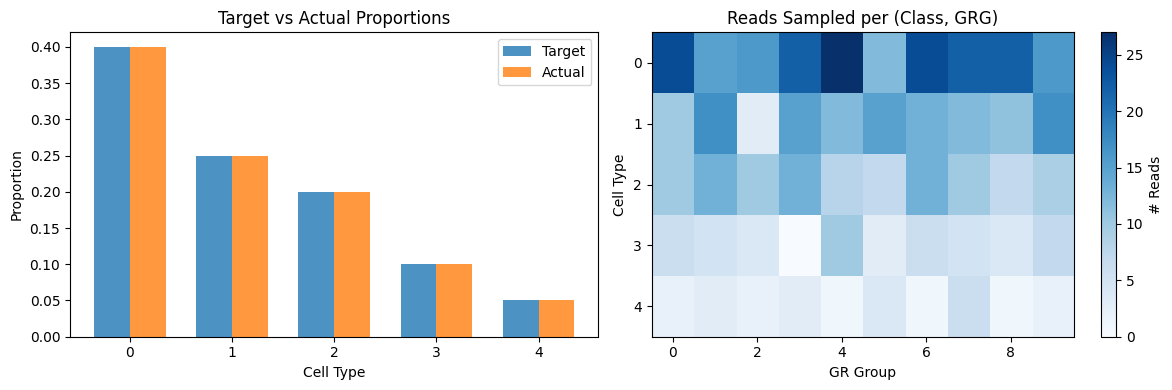

In [29]:
# Visualize the target vs actual proportions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart comparison
x = np.arange(N_CLASSES)
width = 0.35
axes[0].bar(x - width/2, result.target_proportions, width, label='Target', alpha=0.8)
axes[0].bar(x + width/2, result.actual_proportions, width, label='Actual', alpha=0.8)
axes[0].set_xlabel('Cell Type')
axes[0].set_ylabel('Proportion')
axes[0].set_title('Target vs Actual Proportions')
axes[0].legend()
axes[0].set_xticks(x)

# Reads per GRG heatmap
im = axes[1].imshow(result.n_samples_per_class_per_grg, aspect='auto', cmap='Blues')
axes[1].set_xlabel('GR Group')
axes[1].set_ylabel('Cell Type')
axes[1].set_title('Reads Sampled per (Class, GRG)')
plt.colorbar(im, ax=axes[1], label='# Reads')

plt.tight_layout()
plt.show()

## 7. Full Pipeline with PseudobulkGenerator

End-to-end generation using the main class.

In [30]:
# Create a fresh output directory
full_demo_dir = Path(tempfile.mkdtemp(prefix="pseudobulk_full_demo_"))
print(f"Output directory: {full_demo_dir}")

# Create target proportions for each split (small numbers for demo)
n_train_pseudobulks = 100
n_valid_pseudobulks = 50
n_test_pseudobulks = 20

# Random proportions that sum to 1
train_proportions = np.random.dirichlet(np.ones(N_CLASSES), size=n_train_pseudobulks)
valid_proportions = np.random.dirichlet(np.ones(N_CLASSES), size=n_valid_pseudobulks)
test_proportions = np.random.dirichlet(np.ones(N_CLASSES), size=n_test_pseudobulks)

print(f"Target proportions shapes:")
print(f"  Train: {train_proportions.shape}")
print(f"  Valid: {valid_proportions.shape}")
print(f"  Test: {test_proportions.shape}")

Output directory: /tmp/pseudobulk_full_demo_m485zx9f
Target proportions shapes:
  Train: (100, 5)
  Valid: (50, 5)
  Test: (20, 5)


In [31]:
# Initialize the generator
generator = PseudobulkGenerator(
    splits_df={
        "train": train_df,
        "valid": valid_df,
        "test": test_df,
    },
    output_directory=full_demo_dir,
    target_proportions_per_split={
        "train": train_proportions,
        "valid": valid_proportions,
        "test": test_proportions,
    },
    batch_size=5,  # Small batches for demo
    n_workers=2,
    metadata=metadata,
    parameters=parameters,
    n_reads_to_sample=200,  # Small for demo
    grg_grouping_columns=["dmr_ctype_label", "dmr_ctype"],
)

print("PseudobulkGenerator initialized!")
print(f"  Output directory: {generator.output_directory}")
print(f"  Batch size: {generator.batch_size}")
print(f"  Workers: {generator.n_workers}")

PseudobulkGenerator initialized!
  Output directory: /tmp/pseudobulk_full_demo_m485zx9f
  Batch size: 5
  Workers: 2


In [33]:
# Run the full generation pipeline
print("Running full generation pipeline...")
print("="*50)

output_path = generator.run()

print("="*50)
print(f"\n✓ Generation complete!")
print(f"Output file: {output_path}")
print(f"File size: {output_path.stat().st_size / 1024:.1f} KB")

Running full generation pipeline...

✓ Generation complete!
Output file: /tmp/pseudobulk_full_demo_m485zx9f/pseudobulk.h5
File size: 4108.2 KB


## 8. Inspect the Output HDF5 File

Explore the structure and content of the generated HDF5 file.

In [34]:
def print_hdf5_structure(name, obj):
    """Print HDF5 structure with indentation."""
    indent = "  " * name.count("/")
    if isinstance(obj, h5py.Group):
        print(f"{indent}📁 {name}/")
        # Print attributes
        for attr_name, attr_value in obj.attrs.items():
            print(f"{indent}  📎 @{attr_name}: {attr_value}")
    elif isinstance(obj, h5py.Dataset):
        print(f"{indent}📄 {name}: shape={obj.shape}, dtype={obj.dtype}")

# Explore the HDF5 structure
print("HDF5 File Structure:")
print("=" * 50)
with h5py.File(output_path, "r") as f:
    f.visititems(print_hdf5_structure)

HDF5 File Structure:
📁 inputs/
  📁 inputs/metadata/
    📎 @classifier: XGBoost_v2
    📎 @data_watermark: demo_synthetic_data_2026
    📎 @gr_id_column: dmr_ctype_label
    📎 @labeling_scheme: soft_labels
    📄 inputs/metadata/data_stats: shape=(), dtype=object
  📁 inputs/test/
    📎 @n_rows: 2500
    📎 @numeric_columns: ['original_label' 'dmr_ctype_label' 'NCPGS' 'M_rate' 'label'
 'prediction_0' 'prediction_1' 'prediction_2' 'prediction_3'
 'prediction_4']
    📎 @string_columns: ['dmr_ctype' 'name' 'chr']
    📄 inputs/test/numeric_data: shape=(2500, 10), dtype=float64
    📄 inputs/test/string_data: shape=(2500, 3), dtype=object
  📁 inputs/train/
    📎 @n_rows: 5000
    📎 @numeric_columns: ['original_label' 'dmr_ctype_label' 'NCPGS' 'M_rate' 'label'
 'prediction_0' 'prediction_1' 'prediction_2' 'prediction_3'
 'prediction_4']
    📎 @string_columns: ['dmr_ctype' 'name' 'chr']
    📄 inputs/train/numeric_data: shape=(5000, 10), dtype=float64
    📄 inputs/train/string_data: shape=(5000, 3), 

In [35]:
# Read specific data from the HDF5 file
with h5py.File(output_path, "r") as f:
    # Read metadata
    print("Metadata:")
    meta = f["inputs/metadata"]
    print(f"  Classifier: {meta.attrs['classifier']}")
    print(f"  Labeling scheme: {meta.attrs['labeling_scheme']}")
    print(f"  Data watermark: {meta.attrs['data_watermark']}")
    
    # Read parameters
    print("\nParameters:")
    params = f["parameters"]
    print(f"  Substitution method: {params.attrs['substitution_method']}")
    print(f"  GR sampling method: {params.attrs['gr_sampling_method']}")
    
    # Count pseudobulks per split
    print("\nPseudobulks per split:")
    for split in ["train", "valid", "test"]:
        n_pseudobulks = len(f[f"outputs/{split}/pseudobulks"].keys())
        print(f"  {split}: {n_pseudobulks}")

Metadata:
  Classifier: XGBoost_v2
  Labeling scheme: soft_labels
  Data watermark: demo_synthetic_data_2026

Parameters:
  Substitution method: uniform_number
  GR sampling method: uniform_multinomial

Pseudobulks per split:
  train: 100
  valid: 50
  test: 20


In [36]:
# Read and visualize a specific pseudobulk
with h5py.File(output_path, "r") as f:
    # Get first pseudobulk from train split
    pb = f["outputs/train/pseudobulks/i_0"]
    
    target_props = pb["target_proportions"][...]
    actual_props = pb["actual_proportions"][...]
    features = pb["aggregated_features"][...]
    seed = pb.attrs["seed"]
    
    print(f"Pseudobulk i_0 from train split:")
    print(f"  Seed: {seed}")
    print(f"  Target proportions: {target_props}")
    print(f"  Actual proportions: {actual_props}")
    print(f"  Feature matrix shape: {features.shape}")

Pseudobulk i_0 from train split:
  Seed: 313655825
  Target proportions: [0.08304122 0.38130568 0.34887022 0.00992487 0.176858  ]
  Actual proportions: [0.08121827 0.3857868  0.35025381 0.00507614 0.17766497]
  Feature matrix shape: (10, 9)


In [37]:
# Visualize pure profiles if available
with h5py.File(output_path, "r") as f:
    if "outputs/train/pure_profiles" in f:
        pp = f["outputs/train/pure_profiles"]
        feature_matrices = pp["feature_matrices"][...]
        uniform_prior = pp["uniform_prior"][...]
        
        print(f"Pure Profiles (train):")
        print(f"  Feature matrices shape: {feature_matrices.shape}")
        print(f"  Uniform prior shape: {uniform_prior.shape}")
        
        # Plot the pure profiles
        fig, ax = plt.subplots(figsize=(10, 6))
        im = ax.imshow(feature_matrices[:, :, 0], aspect='auto', cmap='viridis')
        ax.set_xlabel('GR Group')
        ax.set_ylabel('Cell Type (pure profile)')
        ax.set_title('Pure Profiles: First Feature Across Cell Types and GRGs')
        plt.colorbar(im, ax=ax, label='Feature Value')
        plt.tight_layout()
        plt.show()
    else:
        print("Pure profiles not found in file")

Pure profiles not found in file


## 9. Cleanup

Remove temporary directories created during the demo.

In [38]:
# Cleanup temporary directories
shutil.rmtree(demo_dir, ignore_errors=True)
shutil.rmtree(full_demo_dir, ignore_errors=True)

print("✓ Cleanup complete!")

✓ Cleanup complete!


## Summary

This notebook demonstrated the key features of the refactored pseudobulk generation pipeline:

1. **Structured data models** - `GenerationMetadata`, `GenerationParameters`, `PseudobulkResult`
2. **Crash-resilient checkpointing** - Atomic JSON writes with per-split checkpoints
3. **Atomic HDF5 batch writing** - Temp file + rename pattern for safe writes
4. **Reproducible generation** - Seeds stored for each pseudobulk
5. **Parallel processing** - Dask-based parallel batch generation
6. **Clean HDF5 output** - Well-structured output with metadata, parameters, and results

### Key Improvements Over Legacy Code

- **Per-split target proportions** - Each split can have different numbers of pseudobulks
- **Better crash resilience** - Checkpoint files separate from HDF5 data
- **Cleaner output format** - Single consolidated HDF5 instead of pickle checkpoints
- **Full reproducibility** - Seeds and parameters stored for exact recreation